# 00 · Start here

**Hybrid QML and Quantum String Algorithms for Document Extraction**
QIntern 2026 · QWorld · [repository](https://github.com/Pushkar0997/qi26_25)

This notebook gets the environment working and runs the whole pipeline once, so
you can see the shape of the thing before opening any of the detailed notebooks.

The pipeline takes a document image and returns extracted text plus the position
of a searched pattern. Two of its five stages are quantum:

```
document image
  └─ segmentation                        classical
      └─ 8×8 character crops
          └─ quanvolutional layer        ← QUANTUM (Track A)
              └─ 160 features per char
                  └─ logistic regression classical OCR head
                      └─ extracted text
                          └─ Grover comparator search   ← QUANTUM (Track B)
                              └─ pattern position
```

**Where to go next**

| Notebook | Contents |
|---|---|
| `01_encoding_frqi_neqr` | How pixels become quantum states; FRQI vs NEQR cost |
| `02_quanvolutional_features` | The quantum feature extractor, and why it loses to raw pixels |
| `03_grover_comparator` | A real string-matching oracle, and why √N does not survive |
| `04_full_pipeline` | Every stage end to end, in detail |
| `05_noise_and_runtimes` | Gate noise, shot noise, GPU and larger runtimes |

Runtime for this notebook: about two minutes, CPU only.

## 1 · Environment

On Colab this clones the repository and installs what is missing. Locally it just finds the repo root.

In [1]:
# Environment setup — works on Colab and on a local checkout.
#
# Safe to run in any order and any number of times. If another notebook in this
# session already cloned the repo, this reuses it rather than trying to clone
# again (which fails with "destination path already exists", exit 128).

import os, sys, subprocess, pathlib, importlib

REPO_URL = "https://github.com/Pushkar0997/qi26_25.git"
REPO_DIR = "qi26_25"
IN_COLAB = "google.colab" in sys.modules

# A file that exists only in this repo, used to recognise a valid checkout.
MARKER = pathlib.Path("integration") / "features.py"


def _is_root(p):
    return (p / MARKER).exists()


def _find_root():
    """Locate the repo, checking three places in order.

    Searching UPWARD alone is not enough. On Colab every notebook gets a fresh
    kernel starting at /content, so a second notebook would look at /content and
    its parents, miss the /content/qi26_25 that the first notebook cloned, and
    try to clone again into a directory that already exists.
    """
    here = pathlib.Path.cwd().resolve()

    # 1. Here or above — a local checkout, or a notebook opened from notebooks/.
    for cand in [here, *here.parents]:
        if _is_root(cand):
            return cand

    # 2. One level down — a clone made earlier in this session.
    for cand in [here / REPO_DIR, pathlib.Path("/content") / REPO_DIR]:
        if _is_root(cand):
            return cand.resolve()

    return None


root = _find_root()
if root is None:
    target = pathlib.Path.cwd() / REPO_DIR
    if target.exists():
        raise SystemExit(
            f"{target} exists but does not contain {MARKER}.\n"
            f"It may be a partial clone. Remove it and re-run this cell:\n"
            f"    !rm -rf {target}")
    print("cloning repository ...")
    subprocess.run(["git", "clone", "--quiet", REPO_URL, str(target)], check=True)
    root = _find_root()
    if root is None:
        raise SystemExit("clone succeeded but the repo layout was not found")
else:
    print("using existing checkout")

os.chdir(root)

# Put the package directories on the path. These modules import each other by
# bare name, so the directories themselves go on sys.path, not the repo root.
for sub in ["integration", "track_b_search/oracle", "data", "benchmarking",
            "track_a_vision/quanvolutional", "track_a_vision/encoding"]:
    d = str(root / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

# Install only what is missing — Colab already ships numpy/scipy/sklearn/PIL.
need = []
for mod, pkg in [("qiskit", "qiskit>=2.0,<3.0"), ("qiskit_aer", "qiskit-aer"),
                 ("sklearn", "scikit-learn"), ("scipy", "scipy"),
                 ("PIL", "pillow"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        need.append(pkg)
if need:
    print("installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)

import qiskit, numpy as np
print("repo root :", root)
print("colab     :", IN_COLAB)
print("qiskit    :", qiskit.__version__, "| numpy:", np.__version__)

using existing checkout


repo root : D:\Coding_Work\qi26_25\qi26_25
colab     : False
qiskit    : 2.5.1 | numpy: 2.5.2


## 2 · Dataset

> **A note on fonts, worth reading before comparing numbers.** The dataset is
> rendered with whatever font the machine provides — Arial on Windows, Liberation
> or DejaVu on Linux and Colab. Glyph outlines differ slightly between them, so
> absolute accuracy figures move by a fraction of a percent depending on where
> you run this. The manifest records exactly which fonts were used.
>
> Every *comparative* conclusion in this project was checked across two
> platforms and was unchanged. If your numbers differ from the report's in the
> third decimal place, that is expected; if a conclusion flips, that is worth
> investigating.

In [2]:
# Generate the dataset if it is not already present (~30 s, deterministic).
#
# IMPORTANT: check for an actual data file, not the manifest. manifest.json is
# committed to the repo (it records the seed, fonts and platform used, which the
# report cites), but the ~8 MB of images and .npz files are gitignored because
# they regenerate exactly from the seed. So on a fresh clone the manifest EXISTS
# while the data does not, and testing the manifest alone wrongly concludes
# everything is ready.
from pathlib import Path
import subprocess, sys, json

TIERS = ["clean_digital", "clean_scan", "noisy_scan",
         "clear_handwriting", "degraded_handwriting"]
have_data = all((Path("data/processed") / t / "chars.npz").exists() for t in TIERS)

if have_data:
    print("dataset already present")
else:
    print("generating dataset (about 30 s) ...")
    subprocess.run([sys.executable, "data/generate_dataset.py",
                    "--docs-per-tier", "12", "--seed", "26"], check=True)

m = json.loads(Path("data/processed/manifest.json").read_text())
print()
print("seed        :", m["seed"])
print("fonts       :", Path(m["font_print"]).name, "/", Path(m["font_hand"]).name)
print("platform    :", m["platform"])
total = sum(t["n_chars"] for t in m["tiers"].values())
for name, t in m["tiers"].items():
    print("  {:22s} {:2d} docs  {:5d} crops".format(name, t["n_docs"], t["n_chars"]))
print("total crops :", total)

dataset already present

seed        : 26
fonts       : arial.ttf / timesi.ttf
platform    : win32
  clean_digital          12 docs   1207 crops
  clean_scan             12 docs   1217 crops
  noisy_scan             12 docs   1200 crops
  clear_handwriting      12 docs   1197 crops
  degraded_handwriting   12 docs   1202 crops
total crops : 6023


## 3 · What the five quality tiers look like

Every tier renders the *same distribution of source text* and then degrades it
differently. That is deliberate: because the content is held constant, any
accuracy difference between tiers is attributable to image quality alone rather
than to some tiers having harder words in them.

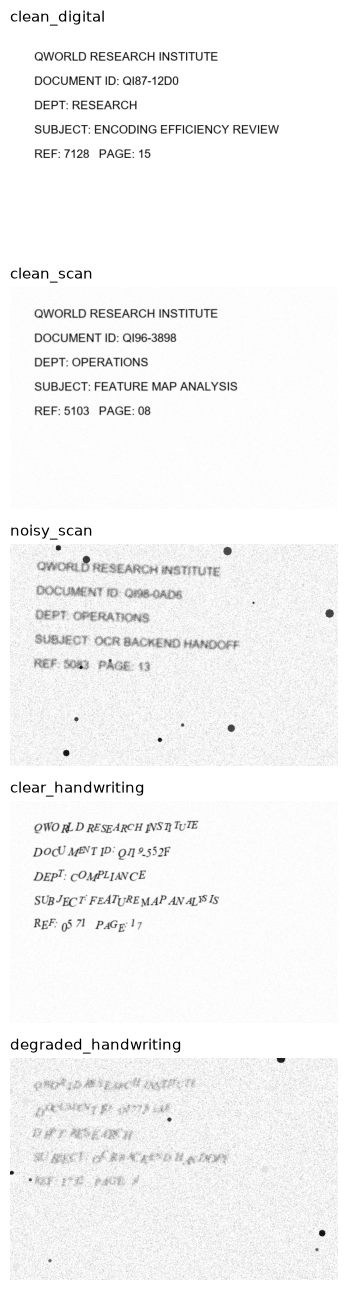

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

TIERS = ["clean_digital", "clean_scan", "noisy_scan",
         "clear_handwriting", "degraded_handwriting"]

# doc_000 is the same source text in every tier, so reading down the column
# isolates degradation from content rather than from harder words.
fig, axes = plt.subplots(len(TIERS), 1, figsize=(9, 13))
for ax, tier in zip(axes, TIERS):
    ax.imshow(Image.open(f"data/processed/{tier}/doc_000.png"), cmap="gray")
    ax.set_title(tier, fontsize=11, loc="left")
    ax.axis("off")
plt.tight_layout(); plt.show()

The degradation is not decorative. Measuring the per-crop dynamic range — how
much contrast survives inside each character box — shows the tiers form a real
difficulty gradient rather than five arbitrary noise settings.

In [4]:
import numpy as np

print(f"{'tier':24s} {'median range':>13s} {'10th pct':>10s}")
# The encoder turns intensity into an angle, RY(pi*v/255), so a crop spanning
# a narrow band of intensities yields an equally narrow band of angles. Range
# is therefore a direct proxy for how much signal survives into the quantum layer.
for tier in TIERS:
    c = np.load(f"data/processed/{tier}/chars.npz")["crops"].astype(float)
    flat = c.reshape(len(c), -1)
    rng = flat.max(1) - flat.min(1)
    print(f"{tier:24s} {np.median(rng):13.0f} {np.percentile(rng, 10):10.0f}")
print("\n255 = full black-to-white contrast inside the crop.")

tier                      median range   10th pct
clean_digital                      169        151
clean_scan                         161        134
noisy_scan                          85         70
clear_handwriting                  144        125
degraded_handwriting                60         50

255 = full black-to-white contrast inside the crop.


## 4 · Train the OCR head

The quantum stage produces features; a small classical model turns them into
characters. Training takes about a minute.

One detail that matters more than it looks: training crops are produced by
running the **real segmentation path** over the training pages, not by cutting
them from the ground-truth glyph boxes recorded at generation time. Those two
give measurably different crops (median 16×19 px versus 12×15 px), and training
on one while predicting on the other cost a 6.6× increase in error before it was
found. Notebook `04` covers that in detail.

In [5]:
import subprocess, sys
from pathlib import Path

# The backend is a gitignored build artefact, so a fresh clone trains once here.
# A stale .npz is reused silently, so delete it after changing the extractor.
if Path("integration/ocr_backend.npz").exists():
    print("backend already trained")
else:
    subprocess.run([sys.executable, "integration/pipeline.py", "--train"], check=True)

backend already trained


## 5 · Run the whole thing once

This takes a document image, extracts its text, locates the identifier field, and
runs Grover's algorithm to find a two-character pattern inside it.

In [6]:
import pipeline as P

# clean_scan rather than clean_digital: the easiest tier that still carries
# scanner artefacts, so the run genuinely exercises the segmentation front end.
result = P.run_document("data/processed/clean_scan/doc_000.png",
                        pattern="38", verbose=True)

FILE : doc_000.png | TIER: clean_scan
SEGMENTED: 94 boxes (truth 99 chars)
--------------------------------------------------------------
EXTRACTED:
QWORLD RESEARCH INSTITUTE
DOCUMENT ID QI96-3898
DEPT OPERATIONS
SUBJECT FEATURE MAP ANALYSIS
REF 5103 PAGE 08
--------------------------------------------------------------
GROUND TRUTH:
QWORLD RESEARCH INSTITUTE
DOCUMENT ID: QI96-3898
DEPT: OPERATIONS
SUBJECT: FEATURE MAP ANALYSIS
REF: 5103   PAGE: 08
--------------------------------------------------------------
CER: 6.2%
--------------------------------------------------------------
GROVER SEARCH:
  searchable_field     963898
  pattern              38
  true_positions       [2]
  grover_position      2
  correct              True
  confidence           0.9419
  iterations           2
  phase_check_ok       True
  uncompute_leakage    0.0


### Reading that output

- **SEGMENTED** — how many character boxes were found, against the true count.
  Under-counting means glyphs merged; over-counting means one glyph was split.
- **CER** — character error rate, the edit distance to the ground truth divided
  by its length. Roughly 6–10% on clean tiers.
- **GROVER** — `uncompute_leakage` should be exactly `0.0`. That is the check
  confirming the oracle's window register returns cleanly to |0⟩, which is what
  makes the search amplify the position register correctly rather than smearing
  amplitude across entangled junk.

If the extracted text looks slightly wrong (`QWQRLD` instead of `QWORLD`), the
most likely cause is a font mismatch — see the note in section 2.

## 6 · The headline results

For context before you dig in, these are the project's main findings. They are
mostly negative, and that is deliberate: a tuned demonstration would have been
easier to produce and worth less.

In [7]:
import json
from pathlib import Path

r = Path("benchmarking/results.json")
if not r.exists():
    print("No results yet. Run:  python benchmarking/run_benchmark.py")
else:
    res = json.loads(r.read_text())
    # The benchmark can be run with --skip, so a partial file is legitimate.
    # Report what is present rather than assuming every experiment ran.
    # dim is printed beside each accuracy because the comparison rests on it:
    # the classical control is sized to emit exactly as many features as the
    # quantum +ZZ readout, so a quantum win cannot be a dimensionality win.
    if "A" in res:
        print("Feature extractors, all tiers pooled, matched dimensionality:")
        for k, v in res["A"]["ALL_TIERS"].items():
            print(f"  {k:32s} {v['acc']:.3f}   (dim {v['dim']})")
    if "D" in res:
        print()
        print(f"Grover oracle CX scaling exponent vs text length: "
              f"{res['D']['cx_exponent']:.2f}")
        print("  (1.0 would be linear; sqrt-N would be 0.5)")
    if "B" in res:
        print()
        print("End-to-end, per tier:")
        for tier, b in res["B"].items():
            print(f"  {tier:24s} CER {b['cer_mean']:6.1%}   "
                  f"ID recovered exactly {b['id_exact_match']:.0%}")
    missing = [k for k in "ABCDE" if k not in res]
    if missing:
        print()
        print(f"(experiments {', '.join(missing)} not in results.json — "
              f"re-run benchmarking/run_benchmark.py without --skip)")

Feature extractors, all tiers pooled, matched dimensionality:
  quanv (marginals)                0.867   (dim 64)
  quanv (+ZZ corr)                 0.922   (dim 160)
  classical conv (dim-matched)     0.919   (dim 160)
  raw pixels                       0.936   (dim 64)

Grover oracle CX scaling exponent vs text length: 1.39
  (1.0 would be linear; sqrt-N would be 0.5)

End-to-end, per tier:
  clean_digital            CER   6.5%   ID recovered exactly 100%
  clean_scan               CER   8.8%   ID recovered exactly 50%
  noisy_scan               CER  78.5%   ID recovered exactly 0%
  clear_handwriting        CER  52.2%   ID recovered exactly 0%
  degraded_handwriting     CER  88.3%   ID recovered exactly 0%


**In words:**

1. The quantum feature layer performs at *parity* with a dimension-matched
   classical convolution, and both lose to raw pixels. Training the quantum
   filter does not close the gap.
2. Grover string matching works correctly, but the gate cost of loading text
   into the oracle grows faster than linearly, so the √N *query* advantage does
   not become an end-to-end speedup.
3. The pipeline's dominant error source is the classical segmentation front end,
   not either quantum stage.
4. A Week 1 prediction made in this project — that the FRQI/NEQR qubit gap would
   widen with patch size — is refuted by measurement. It narrows.

Each of those is derived, with the code that produced it, in the notebooks that
follow.